# HPOBench Random Forest: SMAC surrogate depth comparison

Ten SMAC seeds for each surrogate `max_depth` in `{2, 4, 8, 12, 20}`.

In [5]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

HERE = Path.cwd()
if HERE.name != "02_vehicle_task_53" or HERE.parent.name != "random_forest":
    HERE = Path("experiments/HPOBENCH_depths/random_forest/02_vehicle_task_53").resolve()
paths = sorted((HERE / "smac_output").glob("depth_*/*/trajectory.json"))
results = [json.loads(path.read_text()) for path in paths]
if not results:
    raise FileNotFoundError("No trajectories found. Run run_smac_rf.py first.")
print(f"Loaded {len(results)}/50 trajectories.")
rows = []
for result in results:
    rows.extend({"max_depth": result["max_depth"], "smac_seed": result["smac_seed"], "iteration": i, "best_so_far": best} for i, best in zip(result["iteration"], result["best_so_far"]))
trajectories = pd.DataFrame(rows)
DEPTHS = (2, 4, 8, 12, 20)
colors = dict(zip(DEPTHS, plt.cm.viridis(np.linspace(0.05, 0.95, len(DEPTHS)))))

Loaded 50/50 trajectories.


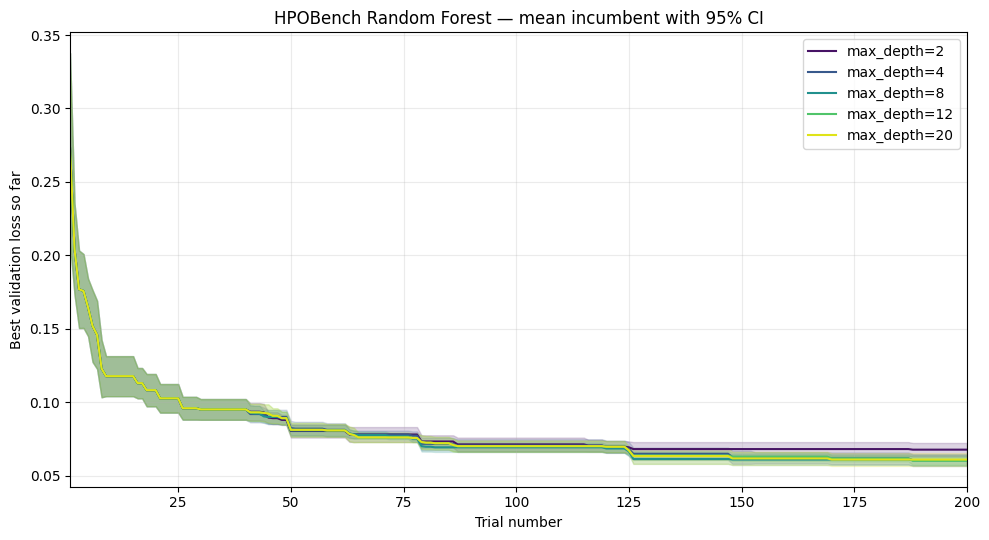

In [6]:
summary = trajectories.groupby(["max_depth", "iteration"])["best_so_far"].agg(["mean", "std", "count"]).reset_index()
summary["ci95"] = 1.96 * summary["std"].fillna(0) / np.sqrt(summary["count"])
fig, ax = plt.subplots(figsize=(10, 5.5))
for depth in DEPTHS:
    data = summary[summary["max_depth"] == depth]
    x, mean, ci = data["iteration"].to_numpy(), data["mean"].to_numpy(), data["ci95"].to_numpy()
    ax.plot(x, mean, color=colors[depth], label=f"max_depth={depth}")
    ax.fill_between(x, mean - ci, mean + ci, color=colors[depth], alpha=0.18)
ax.set(title="HPOBench Random Forest — mean incumbent with 95% CI", xlabel="Trial number", ylabel="Best validation loss so far", xlim=(1, 200))
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

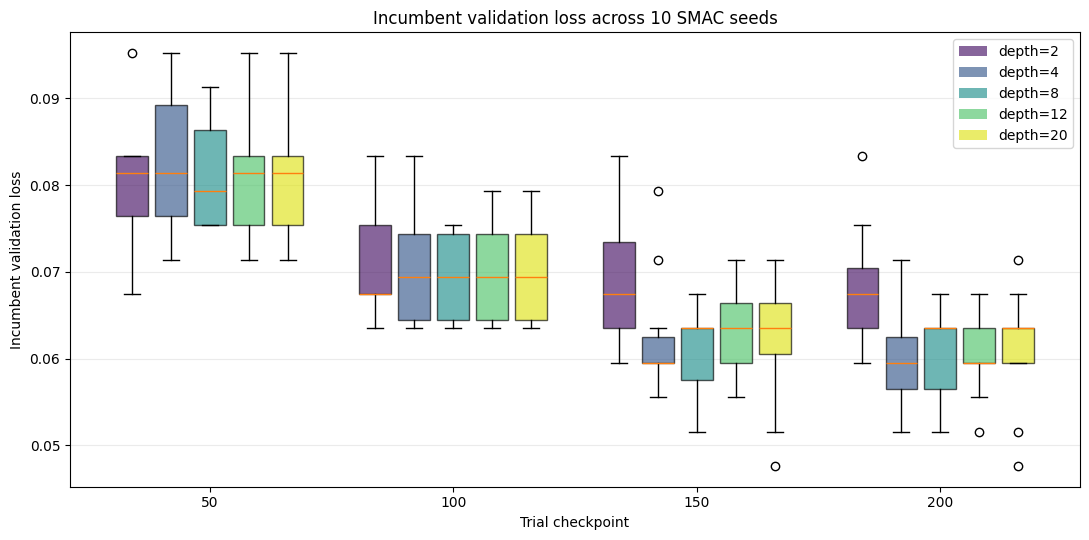

,count,mean,std,min,25%,50%,75%,max
max_depth,,,,,,,,
2,10.0,0.067857,0.007353,0.059524,0.063492,0.067460,0.070437,0.083333
4,10.0,0.060714,0.006494,0.051587,0.056548,0.059524,0.062500,0.071429
8,10.0,0.060714,0.005930,0.051587,0.056548,0.063492,0.063492,0.067460
12,10.0,0.060317,0.004505,0.051587,0.059524,0.059524,0.063492,0.067460
20,10.0,0.061111,0.007049,0.047619,0.059524,0.063492,0.063492,0.071429


In [7]:
checkpoints = (50, 100, 150, 200)
base = np.arange(len(checkpoints))
offsets = dict(zip(DEPTHS, np.linspace(-0.32, 0.32, len(DEPTHS))))
fig, ax = plt.subplots(figsize=(11, 5.5))
for depth in DEPTHS:
    values = [trajectories.loc[(trajectories["max_depth"] == depth) & (trajectories["iteration"] == checkpoint), "best_so_far"].to_numpy() for checkpoint in checkpoints]
    boxes = ax.boxplot(values, positions=base + offsets[depth], widths=0.13, patch_artist=True, manage_ticks=False)
    for box in boxes["boxes"]:
        box.set(facecolor=colors[depth], alpha=0.65)
ax.set(title="Incumbent validation loss across 10 SMAC seeds", xlabel="Trial checkpoint", ylabel="Incumbent validation loss", xticks=base, xticklabels=checkpoints)
ax.legend(handles=[Patch(facecolor=colors[d], alpha=0.65, label=f"depth={d}") for d in DEPTHS])
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()
trajectories[trajectories["iteration"] == 200].groupby("max_depth")["best_so_far"].describe()